In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statistics import mean, stdev

In [2]:
sns.set_style('darkgrid')
cmap=sns.light_palette("seagreen",as_cmap=True)
pd.set_option('display.float_format','{:.4f}'.format)

# Read data

In [3]:
vanilla = pd.read_csv('german-mpa-bin-wout-agg-vanilla_lr-100.csv', index_col=0)
zhang = pd.read_csv('german-mpa-bin-wout-agg-mult_adv-100.csv', index_col=0)

In [4]:
vanilla

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a1_TN_g0,a1_FP_g0,...,a2_FP_g0,a2_FN_g0,a2_TP_g0,a2_TN_g1,a2_FP_g1,a2_FN_g1,a2_TP_g1,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.7167,0.7167,0.6171,0.8170,0.7540,0.9232,19.0000,10.0000,...,34.0000,15.0000,124.0000,19.0000,14.0000,22.0000,60.0000,0.6560,0.5953,0.7604
1,SkVanillaLR,29,0.7200,0.7200,0.6233,0.8922,0.9239,0.9162,14.0000,24.0000,...,41.0000,5.0000,119.0000,21.0000,25.0000,13.0000,65.0000,0.7643,0.7869,0.8063
2,SkVanillaLR,42,0.7333,0.7333,0.6115,0.8879,0.8599,0.9583,13.0000,16.0000,...,41.0000,7.0000,120.0000,16.0000,24.0000,8.0000,74.0000,0.8360,0.7908,0.8988
3,SkVanillaLR,55,0.7033,0.7033,0.6027,0.8575,0.8301,0.9060,15.0000,15.0000,...,43.0000,11.0000,125.0000,20.0000,16.0000,19.0000,56.0000,0.6062,0.5672,0.6701
4,SkVanillaLR,73,0.7400,0.7400,0.6330,0.9581,0.9444,0.9751,14.0000,21.0000,...,31.0000,6.0000,129.0000,22.0000,25.0000,16.0000,63.0000,0.7344,0.7356,0.7556


In [5]:
zhang

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a1_TN_g0,a1_FP_g0,...,a2_FN_g0,a2_TP_g0,a2_TN_g1,a2_FP_g1,a2_FN_g1,a2_TP_g1,wc_spd,wc_aod,wc_eod,last_cosine_similarity
0,MultAdvBin4DP,13,0.6992,0.6992,0.5925,0.7998,0.7586,0.8798,15.0000,11.0000,...,17.0000,98.0000,11.0000,19.0000,16.0000,57.0000,0.7596,0.7145,0.8431,-0.3238
1,MultAdvBin4DP,29,0.7070,0.7070,0.6263,0.9529,0.9229,0.9324,11.0000,25.0000,...,8.0000,91.0000,19.0000,24.0000,11.0000,59.0000,0.8374,0.8094,0.7200,-0.1575
2,MultAdvBin4DP,42,0.7031,0.7031,0.5765,0.8506,0.8378,0.8731,9.0000,13.0000,...,8.0000,101.0000,11.0000,19.0000,14.0000,59.0000,0.8028,0.6894,0.7988,0.0770
3,MultAdvBin4DP,55,0.6641,0.6641,0.5424,0.7667,0.7576,0.7844,11.0000,15.0000,...,13.0000,100.0000,11.0000,19.0000,14.0000,51.0000,0.6723,0.6453,0.7147,-0.0809
4,MultAdvBin4DP,73,0.7383,0.7383,0.6289,0.9866,0.9660,0.9957,9.0000,21.0000,...,8.0000,109.0000,14.0000,25.0000,10.0000,55.0000,0.8433,0.8261,0.8855,0.1595
5,MultAdvBin4EqOdds,13,0.7031,0.7031,0.6000,0.8056,0.7705,0.8798,15.0000,11.0000,...,18.0000,97.0000,12.0000,18.0000,15.0000,58.0000,0.7682,0.7201,0.8544,-0.3285
6,MultAdvBin4EqOdds,29,0.7109,0.7109,0.6260,0.9177,0.9485,0.9166,12.0000,24.0000,...,6.0000,93.0000,19.0000,24.0000,11.0000,59.0000,0.8036,0.8305,0.7200,-0.2304
7,MultAdvBin4EqOdds,42,0.6914,0.6914,0.5570,0.8451,0.8224,0.8808,9.0000,13.0000,...,8.0000,101.0000,11.0000,19.0000,15.0000,58.0000,0.7869,0.6631,0.7988,0.0292
8,MultAdvBin4EqOdds,55,0.6719,0.6719,0.5530,0.7845,0.7760,0.8019,11.0000,15.0000,...,12.0000,101.0000,11.0000,19.0000,14.0000,51.0000,0.6806,0.6596,0.7147,-0.0644
9,MultAdvBin4EqOdds,73,0.7305,0.7305,0.6131,0.9753,0.9888,0.9957,9.0000,21.0000,...,9.0000,108.0000,14.0000,25.0000,9.0000,56.0000,0.8433,0.8396,0.9048,0.2036


In [6]:
zhang[["model_name", "cv_seed", "last_cosine_similarity"]]

,model_name,cv_seed,last_cosine_similarity
0,MultAdvBin4DP,13,-0.3238
1,MultAdvBin4DP,29,-0.1575
2,MultAdvBin4DP,42,0.0770
3,MultAdvBin4DP,55,-0.0809
4,MultAdvBin4DP,73,0.1595
5,MultAdvBin4EqOdds,13,-0.3285
6,MultAdvBin4EqOdds,29,-0.2304
7,MultAdvBin4EqOdds,42,0.0292
8,MultAdvBin4EqOdds,55,-0.0644
9,MultAdvBin4EqOdds,73,0.2036


# Predictive performance

## Acc mean and std

In [6]:
vanilla_acc = vanilla.groupby(['model_name'])['clas_acc'].agg([mean, stdev])
zhang_acc = zhang.groupby(['model_name'])['clas_acc'].agg([mean, stdev])

In [7]:
acc = pd.concat([vanilla_acc, zhang_acc])
acc = acc.reset_index()
acc = acc.rename(columns={'index': 'model_name'})
acc

,model_name,mean,stdev
0,SkVanillaLR,0.7227,0.0144
1,MultAdvBin4DP,0.7023,0.0264
2,MultAdvBin4EqOdds,0.7016,0.0219
3,MultAdvBin4EqOpp,0.7055,0.0222


In [8]:
names = acc['model_name'].to_list()
for i in range(len(names)):
    if isinstance(names[i], tuple):
        names[i] = '-'.join([str(value) for value in names[i]])

names

['SkVanillaLR', 'MultAdvBin4DP', 'MultAdvBin4EqOdds', 'MultAdvBin4EqOpp']

In [9]:
acc['model_name'] = names
acc

,model_name,mean,stdev
0,SkVanillaLR,0.7227,0.0144
1,MultAdvBin4DP,0.7023,0.0264
2,MultAdvBin4EqOdds,0.7016,0.0219
3,MultAdvBin4EqOpp,0.7055,0.0222


In [10]:
print((acc['mean'].round(4).astype(str) + ' $\pm$ ' + acc['stdev'].round(4).astype(str)).to_string(index=False))

0.7227 $\pm$ 0.0144
0.7023 $\pm$ 0.0264
0.7016 $\pm$ 0.0219
0.7055 $\pm$ 0.0222


## Micro-f1 mean and std

In [11]:
vanilla_micro = vanilla.groupby(['model_name'])['f1-micro'].agg([mean, stdev])
zhang_micro = zhang.groupby(['model_name'])['f1-micro'].agg([mean, stdev])

In [12]:
micro = pd.concat([vanilla_micro, zhang_micro])
micro = micro.reset_index()
micro = micro.rename(columns={'index': 'model_name'})
micro

,model_name,mean,stdev
0,SkVanillaLR,0.7227,0.0144
1,MultAdvBin4DP,0.7023,0.0264
2,MultAdvBin4EqOdds,0.7016,0.0219
3,MultAdvBin4EqOpp,0.7055,0.0222


In [13]:
micro['model_name'] = names
micro

,model_name,mean,stdev
0,SkVanillaLR,0.7227,0.0144
1,MultAdvBin4DP,0.7023,0.0264
2,MultAdvBin4EqOdds,0.7016,0.0219
3,MultAdvBin4EqOpp,0.7055,0.0222


In [14]:
print((micro['mean'].round(4).astype(str) + ' $\pm$ ' + micro['stdev'].round(4).astype(str)).to_string(index=False))

0.7227 $\pm$ 0.0144
0.7023 $\pm$ 0.0264
0.7016 $\pm$ 0.0219
0.7055 $\pm$ 0.0222


## Macro-f1 mean and std

In [15]:
vanilla_macro = vanilla.groupby(['model_name'])['f1-macro'].agg([mean, stdev])
zhang_macro = zhang.groupby(['model_name'])['f1-macro'].agg([mean, stdev])

In [16]:
macro = pd.concat([vanilla_macro, zhang_macro])
macro = macro.reset_index()
macro = macro.rename(columns={'index': 'model_name'})
macro

,model_name,mean,stdev
0,SkVanillaLR,0.6175,0.0115
1,MultAdvBin4DP,0.5933,0.0362
2,MultAdvBin4EqOdds,0.5898,0.0331
3,MultAdvBin4EqOpp,0.5978,0.0417


In [17]:
macro['model_name'] = names
macro

,model_name,mean,stdev
0,SkVanillaLR,0.6175,0.0115
1,MultAdvBin4DP,0.5933,0.0362
2,MultAdvBin4EqOdds,0.5898,0.0331
3,MultAdvBin4EqOpp,0.5978,0.0417


In [18]:
print((macro['mean'].round(4).astype(str) + ' $\pm$ ' + macro['stdev'].round(4).astype(str)).to_string(index=False))

0.6175 $\pm$ 0.0115
0.5933 $\pm$ 0.0362
0.5898 $\pm$ 0.0331
0.5978 $\pm$ 0.0417


# Group fairness for first protected attribute

## DP mean and std

In [19]:
vanilla_dp = vanilla.groupby(['model_name'])['a1_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a1_dp'].agg([mean, stdev])

In [20]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.8825,0.0518
1,MultAdvBin4DP,0.8713,0.0955
2,MultAdvBin4EqOdds,0.8657,0.0796
3,MultAdvBin4EqOpp,0.8919,0.0667


In [21]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.8825 $\pm$ 0.0518
0.8713 $\pm$ 0.0955
0.8657 $\pm$ 0.0796
0.8919 $\pm$ 0.0667


## DEqOdds mean and std

In [22]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])

In [23]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.8625,0.0763
1,MultAdvBin4DP,0.8486,0.0946
2,MultAdvBin4EqOdds,0.8612,0.1011
3,MultAdvBin4EqOpp,0.8752,0.0684


In [24]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.8625 $\pm$ 0.0763
0.8486 $\pm$ 0.0946
0.8612 $\pm$ 0.1011
0.8752 $\pm$ 0.0684


## DEqOpp mean and std

In [25]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])

In [26]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.9358,0.0295
1,MultAdvBin4DP,0.8931,0.0782
2,MultAdvBin4EqOdds,0.8950,0.0702
3,MultAdvBin4EqOpp,0.9166,0.0454


In [27]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.9358 $\pm$ 0.0295
0.8931 $\pm$ 0.0782
 0.895 $\pm$ 0.0702
0.9166 $\pm$ 0.0454


# Group fairness for second protected attribute

## DP mean and std

In [28]:
vanilla_dp = vanilla.groupby(['model_name'])['a2_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a2_dp'].agg([mean, stdev])

In [29]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.8087,0.0544
1,MultAdvBin4DP,0.8876,0.0281
2,MultAdvBin4EqOdds,0.8808,0.0387
3,MultAdvBin4EqOpp,0.8937,0.0228


In [30]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.8087 $\pm$ 0.0544
0.8876 $\pm$ 0.0281
0.8808 $\pm$ 0.0387
0.8937 $\pm$ 0.0228


## DEqOdds mean and std

In [31]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])

In [32]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.7947,0.0556
1,MultAdvBin4DP,0.8948,0.0459
2,MultAdvBin4EqOdds,0.8813,0.0488
3,MultAdvBin4EqOpp,0.8996,0.0431


In [33]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.7947 $\pm$ 0.0556
0.8948 $\pm$ 0.0459
0.8813 $\pm$ 0.0488
0.8996 $\pm$ 0.0431


## DEqOpp mean and std

In [34]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])

In [35]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.8681,0.0529
1,MultAdvBin4DP,0.9096,0.0192
2,MultAdvBin4EqOdds,0.9103,0.0342
3,MultAdvBin4EqOpp,0.9129,0.0300


In [36]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.8681 $\pm$ 0.0529
0.9096 $\pm$ 0.0192
0.9103 $\pm$ 0.0342
  0.9129 $\pm$ 0.03


# Intersectional Fairness

## WCSPD mean and std

In [37]:
vanilla_wcspd = vanilla.groupby(['model_name'])['wc_spd'].agg([mean, stdev])
zhang_wcspd = zhang.groupby(['model_name'])['wc_spd'].agg([mean, stdev])

In [38]:
wcspd = pd.concat([vanilla_wcspd, zhang_wcspd])
wcspd = wcspd.reset_index()
wcspd = wcspd.rename(columns={'index': 'model_name'})
wcspd['model_name'] = names
wcspd

,model_name,mean,stdev
0,SkVanillaLR,0.7194,0.0904
1,MultAdvBin4DP,0.7831,0.0703
2,MultAdvBin4EqOdds,0.7765,0.0604
3,MultAdvBin4EqOpp,0.8111,0.0315


In [39]:
print((wcspd['mean'].round(4).astype(str) + ' $\pm$ ' + wcspd['stdev'].round(4).astype(str)).to_string(index=False))

0.7194 $\pm$ 0.0904
0.7831 $\pm$ 0.0703
0.7765 $\pm$ 0.0604
0.8111 $\pm$ 0.0315


## WCAOD mean and std

In [40]:
vanilla_wcaod = vanilla.groupby(['model_name'])['wc_aod'].agg([mean, stdev])
zhang_wcaod = zhang.groupby(['model_name'])['wc_aod'].agg([mean, stdev])

In [41]:
wcaod = pd.concat([vanilla_wcaod, zhang_wcaod])
wcaod = wcaod.reset_index()
wcaod = wcaod.rename(columns={'index': 'model_name'})
wcaod['model_name'] = names
wcaod

,model_name,mean,stdev
0,SkVanillaLR,0.6952,0.1067
1,MultAdvBin4DP,0.7369,0.0780
2,MultAdvBin4EqOdds,0.7426,0.0878
3,MultAdvBin4EqOpp,0.7971,0.0610


In [42]:
print((wcaod['mean'].round(4).astype(str) + ' $\pm$ ' + wcaod['stdev'].round(4).astype(str)).to_string(index=False))

0.6952 $\pm$ 0.1067
 0.7369 $\pm$ 0.078
0.7426 $\pm$ 0.0878
 0.7971 $\pm$ 0.061


## WCEOD mean and std

In [43]:
vanilla_wceod = vanilla.groupby(['model_name'])['wc_eod'].agg([mean, stdev])
zhang_wceod = zhang.groupby(['model_name'])['wc_eod'].agg([mean, stdev])

In [44]:
wceod = pd.concat([vanilla_wceod, zhang_wceod])
wceod = wceod.reset_index()
wceod = wceod.rename(columns={'index': 'model_name'})
wceod['model_name'] = names
wceod

,model_name,mean,stdev
0,SkVanillaLR,0.7782,0.0834
1,MultAdvBin4DP,0.7924,0.0751
2,MultAdvBin4EqOdds,0.7985,0.0831
3,MultAdvBin4EqOpp,0.8085,0.0566


In [45]:
print((wceod['mean'].round(4).astype(str) + ' $\pm$ ' + wceod['stdev'].round(4).astype(str)).to_string(index=False))

0.7782 $\pm$ 0.0834
0.7924 $\pm$ 0.0751
0.7985 $\pm$ 0.0831
0.8085 $\pm$ 0.0566


# T-test

In [46]:
vanilla_lr = vanilla
zhang4dp, zhang4deqodds, zhang4deqopp = [x for _, x in zhang.groupby(['model_name'])]

In [47]:
models = [
    vanilla_lr,
    zhang4dp, zhang4deqodds, zhang4deqopp
]

In [48]:
alpha = 0.05 # significance level
confidence = 1 - alpha # confidence level
l = len(models)

In [49]:
base_df = pd.DataFrame(index=names, columns=names, dtype=object)

## for accuracies

In [50]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['clas_acc'], models[j]['clas_acc'])
        res_acc.iloc[i, j] = stat[1]

In [51]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0366,-,-,-
MultAdvBin4EqOdds,0.0333,0.8466,-,-
MultAdvBin4EqOpp,0.1213,0.7003,0.4734,-


In [52]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-micro'], models[j]['f1-micro'])
        res_acc.iloc[i, j] = stat[1]

In [53]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0366,-,-,-
MultAdvBin4EqOdds,0.0333,0.8466,-,-
MultAdvBin4EqOpp,0.1213,0.7003,0.4734,-


In [54]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-macro'], models[j]['f1-macro'])
        res_acc.iloc[i, j] = stat[1]

In [55]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0993,-,-,-
MultAdvBin4EqOdds,0.0611,0.5969,-,-
MultAdvBin4EqOpp,0.2540,0.7375,0.4288,-


## for group fairness A1

In [56]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_dp'], models[j]['a1_dp'])
        res_dp.iloc[i, j] = stat[1]

In [57]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.6921,-,-,-
MultAdvBin4EqOdds,0.4123,0.5588,-,-
MultAdvBin4EqOpp,0.4589,0.2720,0.0418,-


In [58]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqodds'], models[j]['a1_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [59]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.4413,,,
MultAdvBin4EqOdds,0.9512,0.1617,,
MultAdvBin4EqOpp,0.3144,0.1223,0.4043,


In [60]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqopp'], models[j]['a1_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [61]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.2005,,,
MultAdvBin4EqOdds,0.1545,0.7499,,
MultAdvBin4EqOpp,0.2235,0.2993,0.2294,


## for group fairness A2

In [62]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_dp'], models[j]['a2_dp'])
        res_dp.iloc[i, j] = stat[1]

In [63]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0619,-,-,-
MultAdvBin4EqOdds,0.1191,0.3343,-,-
MultAdvBin4EqOpp,0.0630,0.6724,0.4402,-


In [64]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqodds'], models[j]['a2_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [65]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.0488,,,
MultAdvBin4EqOdds,0.0984,0.0974,,
MultAdvBin4EqOpp,0.0636,0.7531,0.1878,


In [66]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqopp'], models[j]['a2_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [67]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.2385,,,
MultAdvBin4EqOdds,0.3038,0.9427,,
MultAdvBin4EqOpp,0.1859,0.8720,0.9264,


## for intersectional fairness

In [68]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_spd'], models[j]['wc_spd'])
        res_dp.iloc[i, j] = stat[1]

In [69]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0678,-,-,-
MultAdvBin4EqOdds,0.1266,0.4652,-,-
MultAdvBin4EqOpp,0.0437,0.1893,0.0721,-


In [70]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_aod'], models[j]['wc_aod'])
        res_deqodds.iloc[i, j] = stat[1]

In [71]:
res_deqodds.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.3452,-,-,-
MultAdvBin4EqOdds,0.3586,0.5368,-,-
MultAdvBin4EqOpp,0.0721,0.0028,0.0107,-


In [72]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_eod'], models[j]['wc_eod'])
        res_deqopp.iloc[i, j] = stat[1]

In [73]:
res_deqopp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.7729,-,-,-
MultAdvBin4EqOdds,0.7015,0.1971,-,-
MultAdvBin4EqOpp,0.5006,0.4844,0.6998,-


# Plotting

## Plotting Accuracies

In [74]:
model_names = vanilla['model_name'].to_list()
model_names += zhang['model_name'].to_list()

In [75]:
model_names

['SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp']

In [76]:
model_accs = vanilla['clas_acc'].to_list()+zhang['clas_acc'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26167/1516234898.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


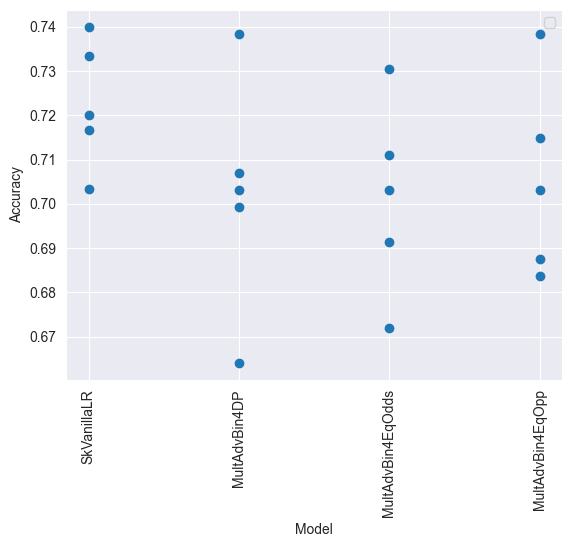

In [77]:
plt.plot()
plt.ylabel('Accuracy')

plt.scatter(model_names, model_accs)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Demographic Disparities

In [78]:
model_spd = vanilla['wc_spd'].to_list()+zhang['wc_spd'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26167/545090117.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


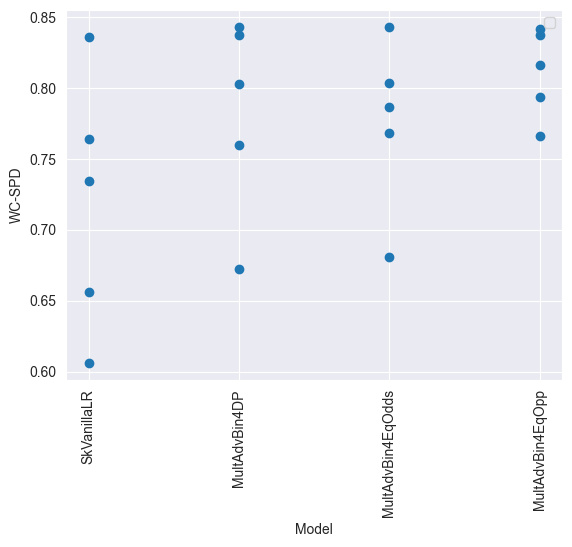

In [79]:
plt.plot()
plt.ylabel('WC-SPD')

plt.scatter(model_names, model_spd)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Odds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26167/1727290324.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


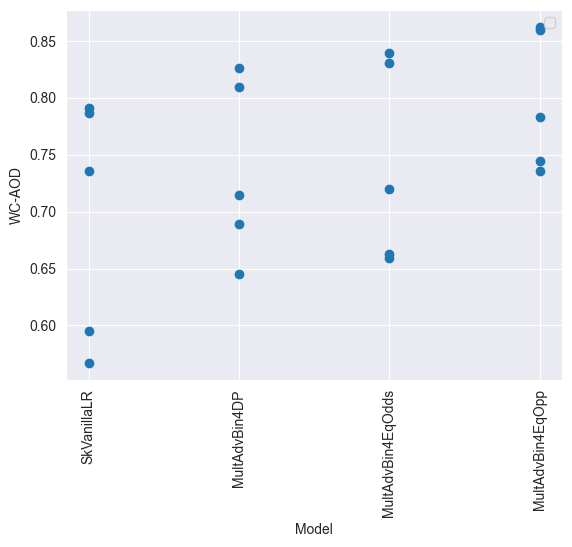

In [80]:
model_aod = vanilla['wc_aod'].to_list()+zhang['wc_aod'].to_list()
plt.plot()
plt.ylabel('WC-AOD')

plt.scatter(model_names, model_aod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Opp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26167/2617305754.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


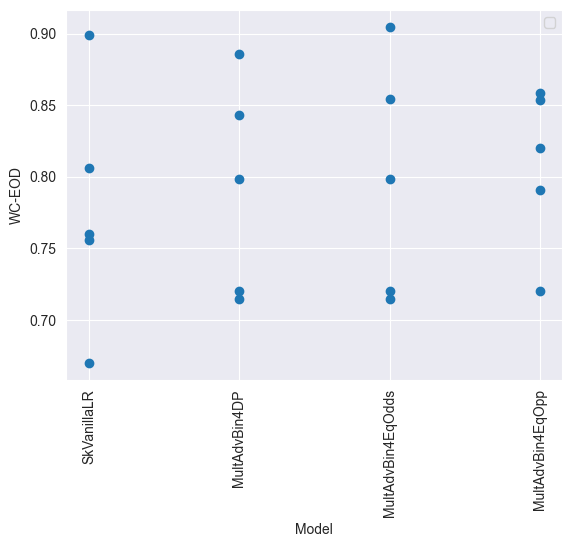

In [81]:
model_eod = vanilla['wc_eod'].to_list()+zhang['wc_eod'].to_list()
plt.plot()
plt.ylabel('WC-EOD')

plt.scatter(model_names, model_eod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Acc x WC-SPD

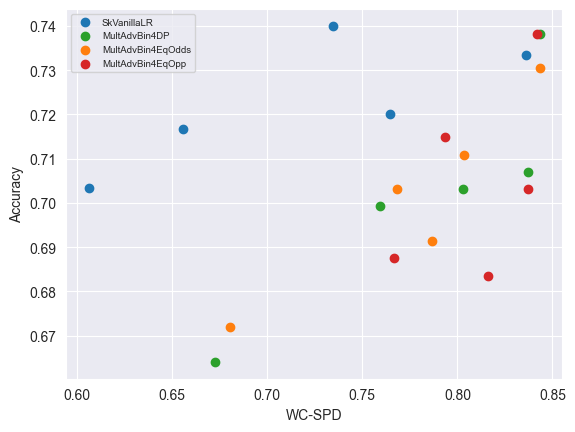

<Figure size 700x700 with 0 Axes>

In [82]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-SPD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_spd[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-AOD

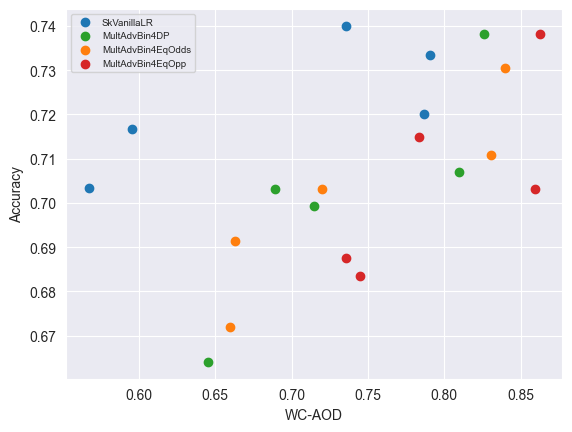

<Figure size 700x700 with 0 Axes>

In [83]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-AOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_aod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-EOD

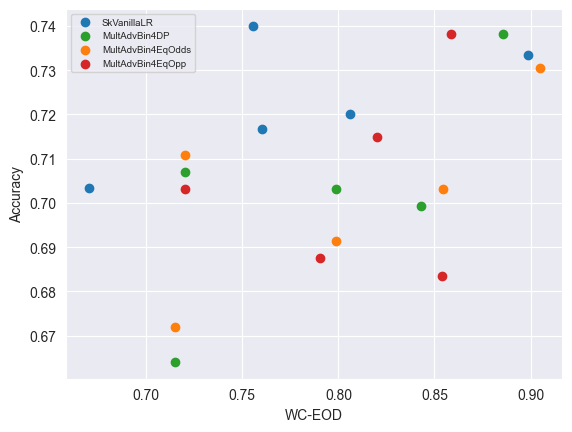

<Figure size 700x700 with 0 Axes>

In [84]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-EOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_eod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()